(1029, 1500, 3)


C:\Users\ACER\AppData\Local\Temp\ipykernel_13072\239057025.py:27: UserWarning: threshold_otsu is expected to work correctly only for grayscale images; image shape (340, 490, 3) looks like that of an RGB image.
  thres = threshold_otsu(a)


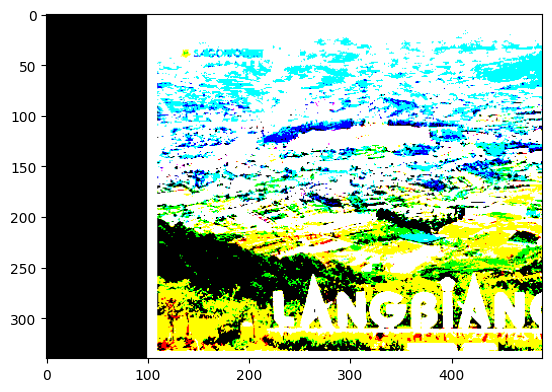

In [45]:
# 1.Viết chương trình chọn Lang Biang trong ảnh Đà Lạt từ thư mục exercise. Tịnh tiến vùng chọn sang phải 100px. Sử dụng phương pháp Otsu để phân vùng Lang Biang theo ngường 0.3. Lưu vào máy với tên lang_biang.jpgvà hiển thị trên màn hình.
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_otsu

data = iio.imread('./exercise/dalat.jpg')

# Chọn hình Lang Biang
LB = data[10:350, 10:500]
print(data.shape)

# Tịnh tiến qua phải 100px
bdata = nd.shift(LB, (0, 100, 0))

# Chuyển đổi sang mảng numpy
a = np.asarray(bdata)

# Chuyển đổi sang ảnh grayscale
# a_gray = cv2.cvtColor(a, cv2.COLOR_RGB2GRAY)

# Áp dụng phương pháp Otsu để phân vùng
thres = threshold_otsu(a)
b = a > thres

# Chuyển đổi mảng nhị phân thành hình ảnh
b_image = Image.fromarray((b * 255).astype(np.uint8))

# Lưu hình ảnh
b_image.save('lang_biang.jpg')

# Hiển thị trên màn hình
plt.imshow(b_image)
plt.show()

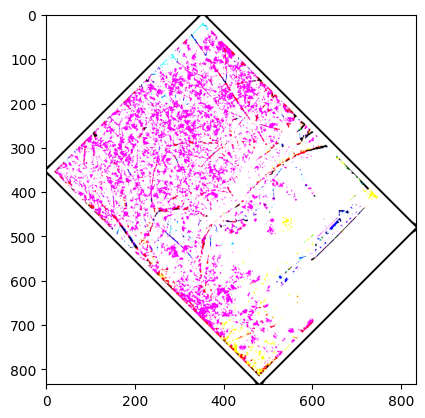

In [46]:
# 2. Viết chương trình chọn Hồ Xuân Hương trong ảnh Đà Lạt từ thư mục exercise. Xoay đối tượng vừa chọn 1 góc 45° và dùng phương pháp Adaptive Thresholding với ngưỡng 60 và lưu vào máy với tên là ho_xuan_huong.jpg.
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_local

data = iio.imread('./exercise/dalat.jpg')
# Chọn ảnh Hồ Xuân Hương
hxh = data[10:690, 500:1000]
# Xoay ảnh 45 độ
hxh_rotate = nd.rotate(hxh, 45)
# Chuyển đổi sang mảng numpy
a = np.asarray(hxh_rotate)
# Áp dụng phương pháp Adaptive Thresholding với ngưỡng 60
# Sử dụng threshold_local để tạo ngưỡng cục bộ
thres = threshold_local(a, 39, offset=60)
b = a > thres
# Chuyển đổi mảng nhị phân thành hình ảnh
b_image = Image.fromarray((b * 255).astype(np.uint8))
# Lưu hình ảnh
b_image.save('ho_xuan_huong.jpg')
# Hiển thị trên màn hình
plt.imshow(b_image)
plt.show()

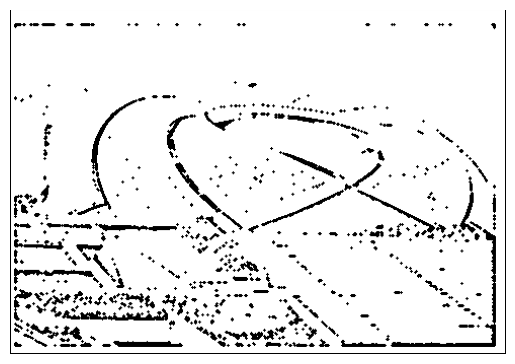

In [ ]:
# 3. Viết chương trình chọn Quản trường Lâm Viên trong ảnh Đà Lạt từ thư mục exercise. Dùng phương pháp Coordinate Mapping và Binary Closing cho vùng vừa chọn. Lưu vào máy với tên là quan_truong_lam_vien.jpg.
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import binary_closing
import matplotlib.pylab as plt
from skimage.filters import threshold_local

# Đọc ảnh Đà Lạt
data = iio.imread('./exercise/dalat.jpg')

# Chọn ảnh Quản trường Lâm Viên
qtlv = data[10:350, 1000:1490]

# Chuyển đổi sang ảnh xám nếu ảnh có nhiều kênh màu
if len(qtlv.shape) == 3:
    qtlv_gray = np.mean(qtlv, axis=2)  # Tính trung bình các kênh màu
else:
    qtlv_gray = qtlv

# Áp dụng ngưỡng địa phương để tạo ảnh nhị phân
block_size = 15
thresh = threshold_local(qtlv_gray, block_size=block_size, offset=10)
binary = qtlv_gray > thresh

# Áp dụng binary closing
closed = binary_closing(binary)

# Chuyển đổi ảnh nhị phân đã đóng về định dạng uint8 để lưu
closed_image = (closed * 255).astype(np.uint8)

# Lưu ảnh kết quả
iio.imwrite('quan_truong_lam_vien.jpg', closed_image)

# Hiển thị ảnh kết quả
plt.imshow(closed_image, cmap='gray')
plt.axis('off')
plt.show()

Chọn chức năng xử lý hình ảnh:
1. Geometric Transformation
2. Segment
3. Sử dụng cả hai chức năng
4. Thoát


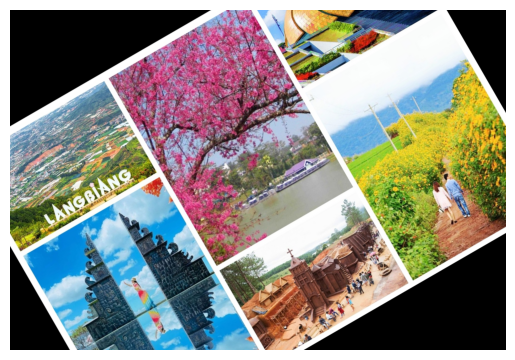

Chọn chức năng xử lý hình ảnh:
1. Geometric Transformation
2. Segment
3. Sử dụng cả hai chức năng
4. Thoát


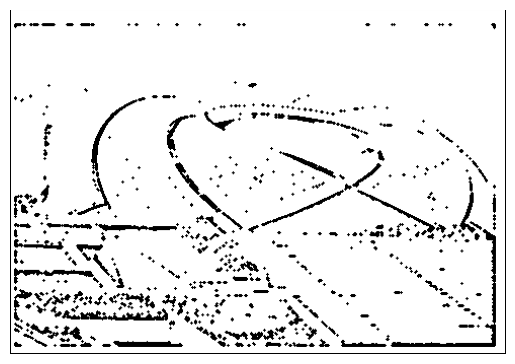

Chọn chức năng xử lý hình ảnh:
1. Geometric Transformation
2. Segment
3. Sử dụng cả hai chức năng
4. Thoát


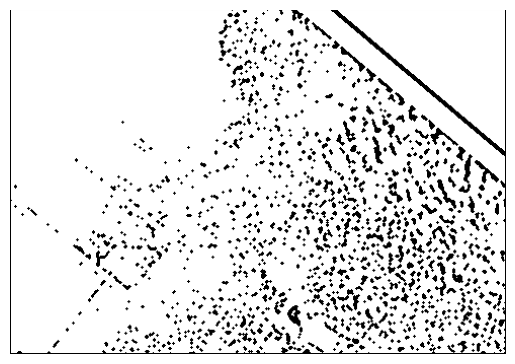

Chọn chức năng xử lý hình ảnh:
1. Geometric Transformation
2. Segment
3. Sử dụng cả hai chức năng
4. Thoát
Thoát chương trình.


In [ ]:
# 4. Viết chương trình cho phép người dùng nhập chức năng muốn xử lý. (Có thể chọn 1 chức năng duy nhất hoặc kết hợp 2 chức năng của geometric_transformation và segment)
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label, binary_closing
import matplotlib.pylab as plt
from skimage.filters import threshold_local

def geometric_transformation(image):
    # Thực hiện một phép biến đổi hình học đơn giản (ví dụ: xoay ảnh)
    angle = float(input("Nhập góc xoay (độ): "))
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h))
    return rotated

def segment(image):
    # Chọn vùng Quản trường Lâm Viên
    qtlv = image[10:350, 1000:1490]
    
    # Chuyển đổi sang ảnh xám
    if len(qtlv.shape) == 3:
        qtlv_gray = np.mean(qtlv, axis=2)  # Tính trung bình các kênh màu
    else:
        qtlv_gray = qtlv

    # Áp dụng ngưỡng địa phương để tạo ảnh nhị phân
    block_size = 15
    thresh = threshold_local(qtlv_gray, block_size=block_size, offset=10)
    binary = qtlv_gray > thresh

    # Áp dụng binary closing
    closed = binary_closing(binary)

    # Chuyển đổi ảnh nhị phân đã đóng về định dạng uint8 để lưu
    closed_image = (closed * 255).astype(np.uint8)

    # Lưu ảnh kết quả
    iio.imwrite('quan_truong_lam_vien.jpg', closed_image)

    # Hiển thị ảnh kết quả
    plt.imshow(closed_image, cmap='gray')
    plt.axis('off')
    plt.show()

def main():
    # Đọc ảnh Đà Lạt
    data = iio.imread('./exercise/dalat.jpg')

    while True:
        print("Chọn chức năng xử lý hình ảnh:")
        print("1. Geometric Transformation")
        print("2. Segment")
        print("3. Sử dụng cả hai chức năng")
        print("4. Thoát")
        
        choice = input("Nhập lựa chọn của bạn (1/2/3/4): ")

        if choice == '1':
            transformed_image = geometric_transformation(data)
            plt.imshow(transformed_image)
            plt.axis('off')
            plt.show()
        elif choice == '2':
            segment(data)
        elif choice == '3':
            transformed_image = geometric_transformation(data)
            segment(transformed_image)
        elif choice == '4':
            print("Thoát chương trình.")
            break
        else:
            print("Lựa chọn không hợp lệ. Vui lòng thử lại.")

if __name__ == "__main__":
    main()
